In [26]:
# Setup
import sys
sys.path.append('../')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")

In [27]:
# Define models to analyze
MODELS = [
    "lightgbm_44features",
    "xgboost_44features", 
    "random_forest_44features"
]

In [28]:
# Load all CSVs for all models
all_results = {}

for model_name in MODELS:
    try:
        sex_df = pd.read_csv(f"../results/fairness/{model_name}_sex.csv")
        edu_df = pd.read_csv(f"../results/fairness/{model_name}_education.csv")
        mar_df = pd.read_csv(f"../results/fairness/{model_name}_marriage.csv")
        
        all_results[model_name] = {
            "sex": sex_df,
            "education": edu_df,
            "marriage": mar_df
        }
        print(f"✓ Loaded: {model_name}")
    except FileNotFoundError:
        print(f"✗ Missing: {model_name} (run 'py src/fairness_analysis.py' first)")

print(f"\nTotal models loaded: {len(all_results)}")

✓ Loaded: lightgbm_44features
✓ Loaded: xgboost_44features
✓ Loaded: random_forest_44features

Total models loaded: 3


In [29]:
# Display all tables
for model_name, results in all_results.items():
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")
    
    for demo_name, df in results.items():
        print(f"\n--- {demo_name.upper()} ---")
        print(df.to_string(index=False))


MODEL: lightgbm_44features

--- SEX ---
 Group  Count  Default_Rate  Approval_Rate  Accuracy  Precision   Recall       F1      FPR      FNR
  Male   1766      0.253681       0.678369  0.727067   0.470070 0.595982 0.525591 0.228376 0.404018
Female   2734      0.200439       0.724579  0.780176   0.464807 0.638686 0.538048 0.184355 0.361314

--- EDUCATION ---
          Group  Count  Default_Rate  Approval_Rate  Accuracy  Precision   Recall       F1      FPR      FNR
Graduate School   1580      0.202532       0.751266  0.781646   0.468193 0.575000 0.516129 0.165873 0.425000
     University   2086      0.228667       0.687919  0.758389   0.479263 0.654088 0.553191 0.210690 0.345912
    High School    766      0.257180       0.646214  0.702350   0.442804 0.609137 0.512821 0.265378 0.390863
          Other     20      0.050000       0.900000  0.950000   0.500000 1.000000 0.666667 0.052632 0.000000
        Unknown     40      0.025000       0.925000  0.900000   0.000000 0.000000 0.000000 0.07

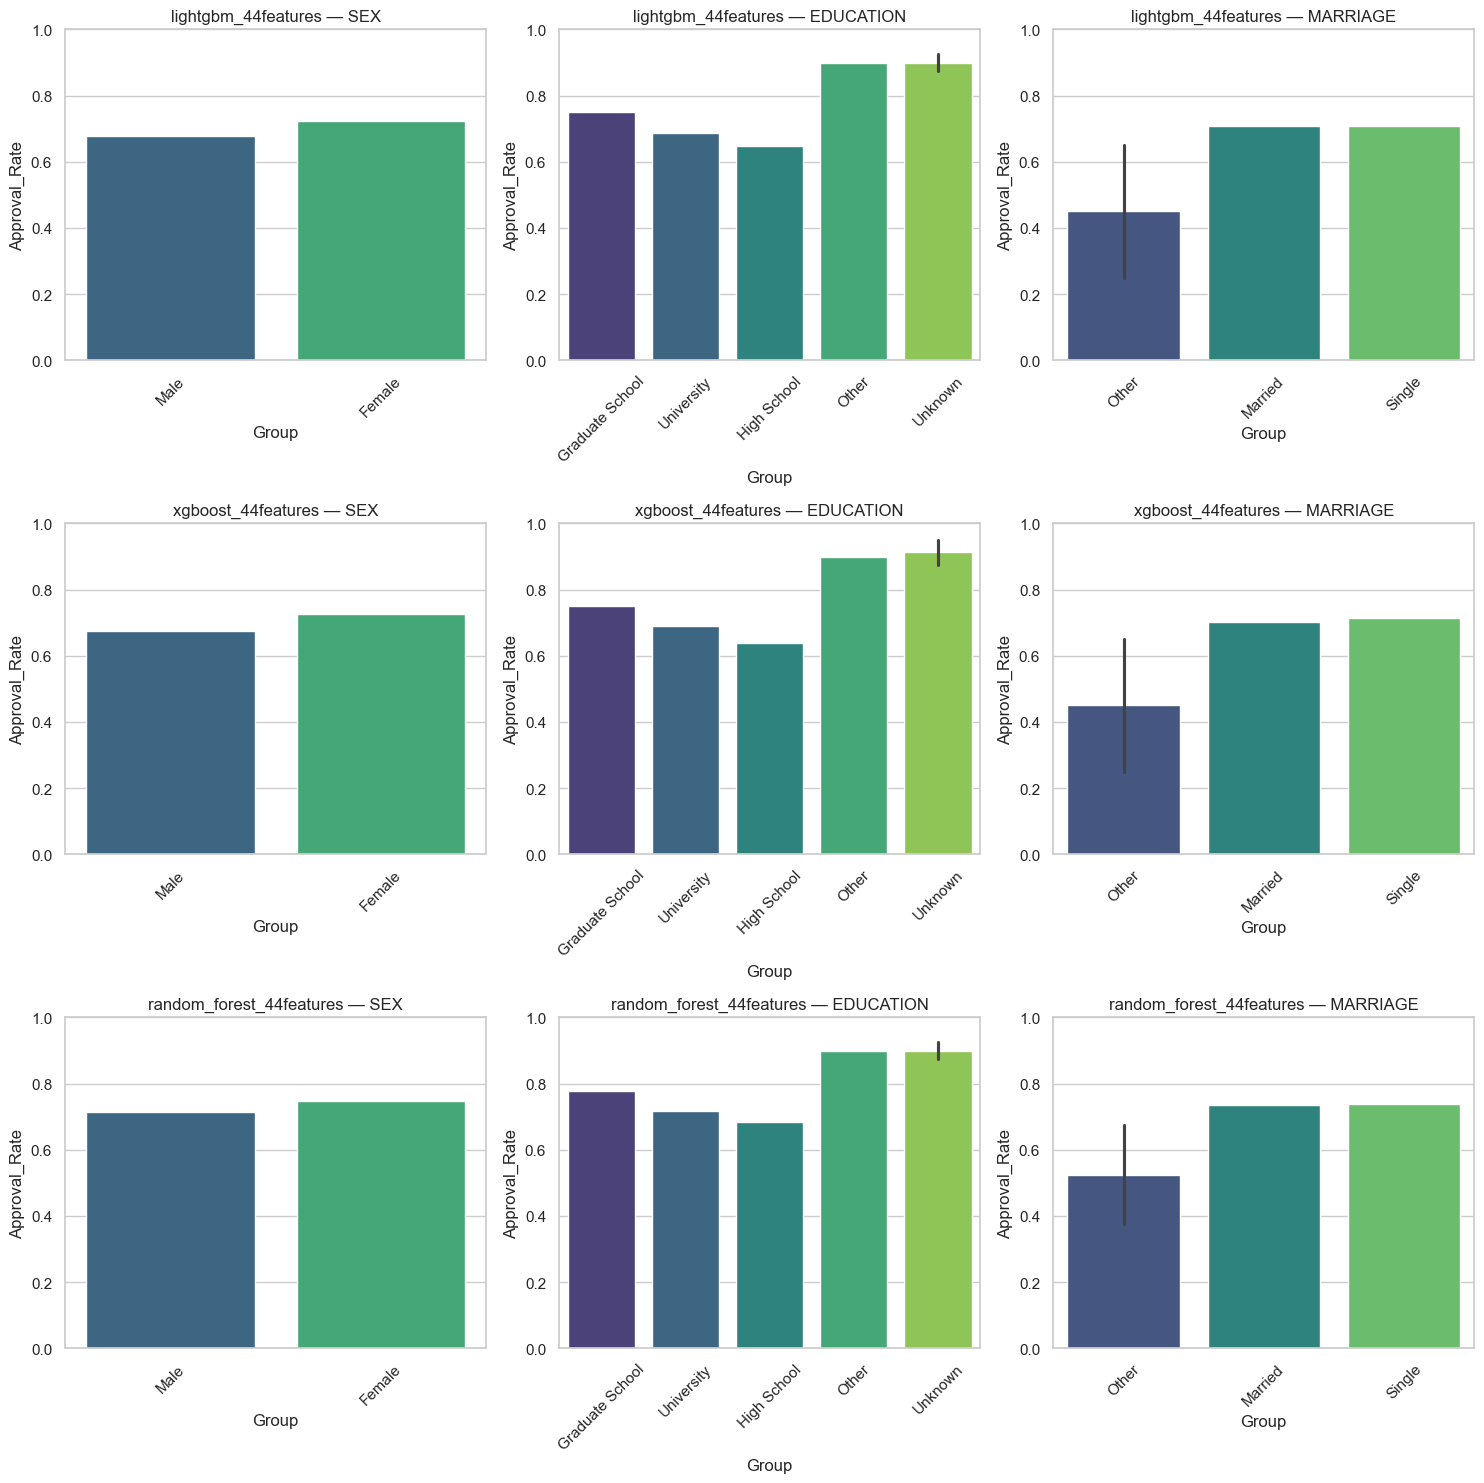

In [30]:
# Plot comparison — Approval Rates across all models
fig, axes = plt.subplots(len(all_results), 3, figsize=(15, 5 * len(all_results)))

if len(all_results) == 1:
    axes = axes.reshape(1, -1)

for row_idx, (model_name, results) in enumerate(all_results.items()):
    for col_idx, (demo_name, df) in enumerate(results.items()):
        ax = axes[row_idx, col_idx] if len(all_results) > 1 else axes[col_idx]
        sns.barplot(data=df, x="Group", y="Approval_Rate", hue="Group", ax=ax, palette="viridis", legend=False)
        ax.set_title(f"{model_name} — {demo_name.upper()}")
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../results/fairness/all_models_approval_rates.png", dpi=300, bbox_inches="tight")
plt.show()

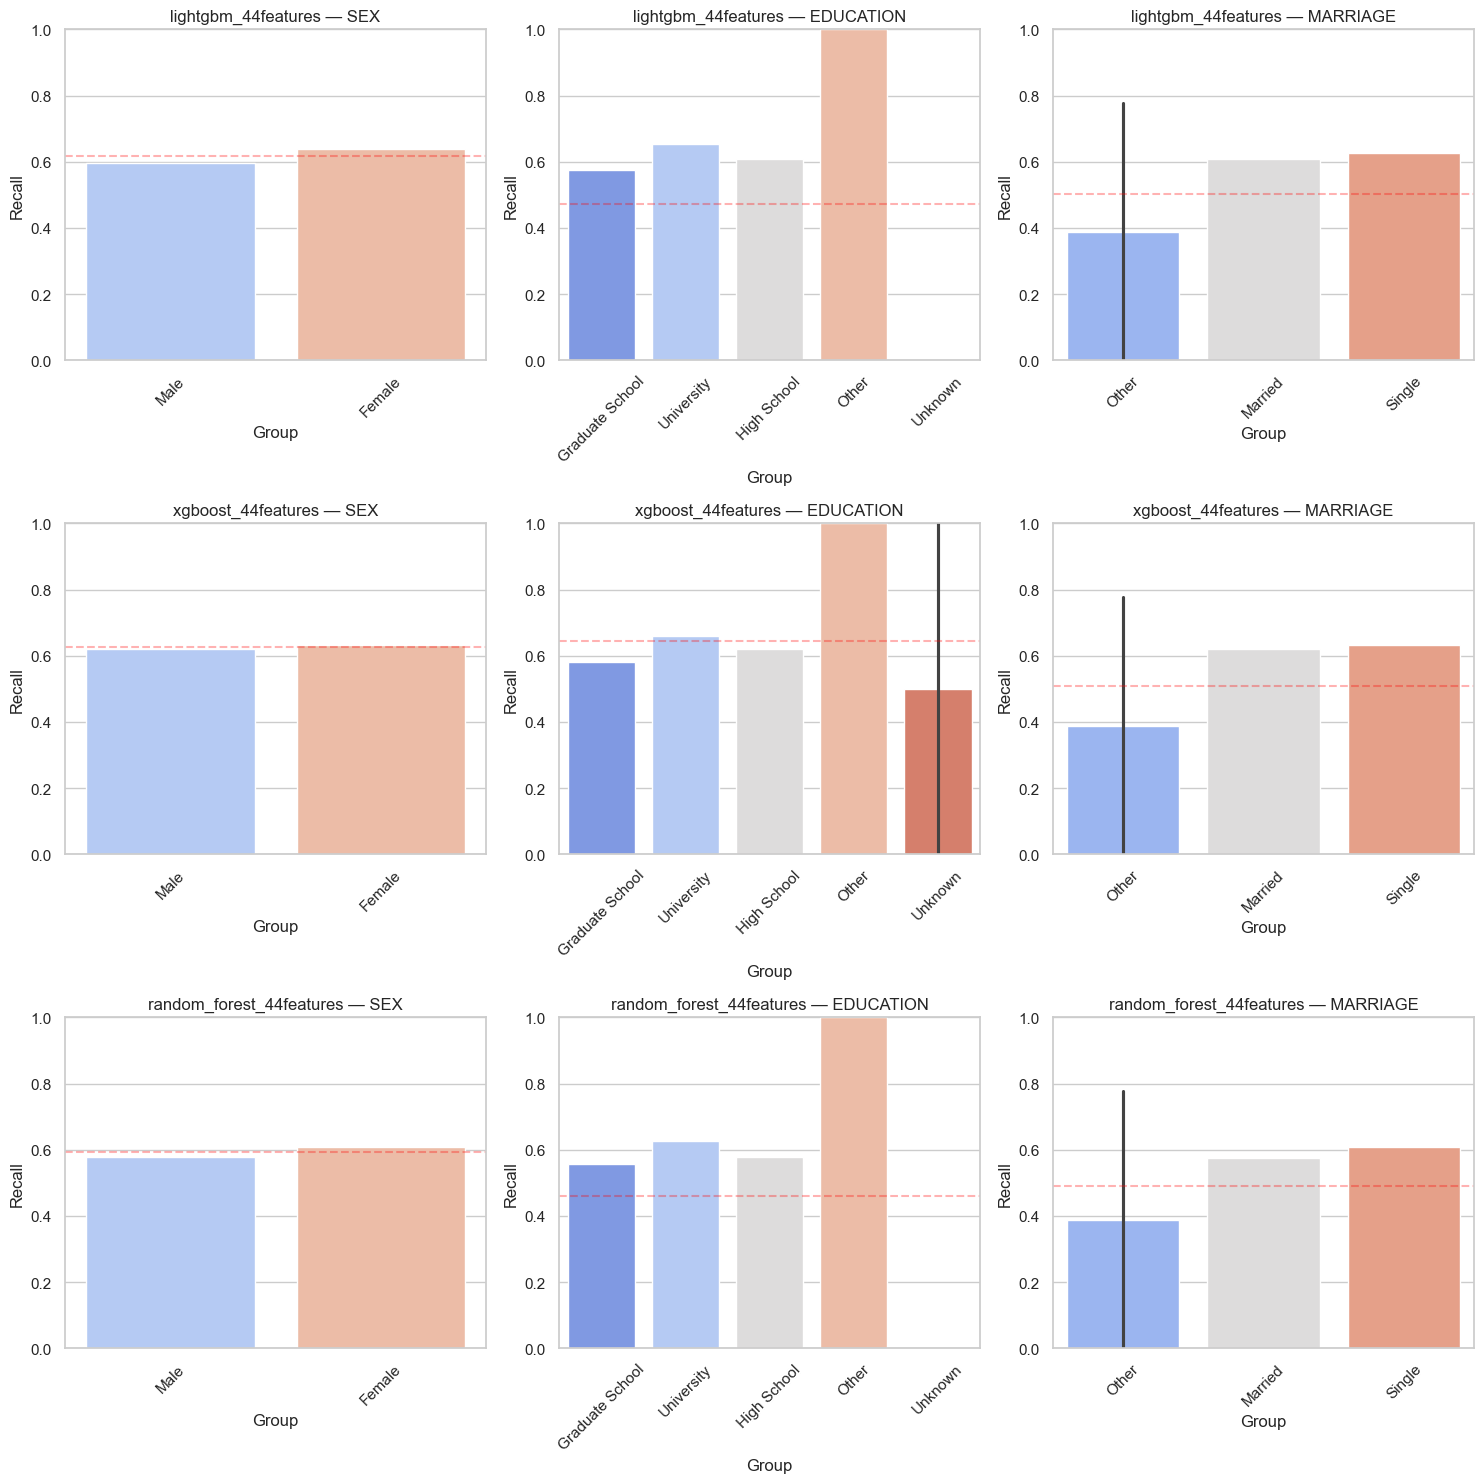

In [31]:
# Plot comparison — Recall across all models
fig, axes = plt.subplots(len(all_results), 3, figsize=(15, 5 * len(all_results)))

if len(all_results) == 1:
    axes = axes.reshape(1, -1)

for row_idx, (model_name, results) in enumerate(all_results.items()):
    for col_idx, (demo_name, df) in enumerate(results.items()):
        ax = axes[row_idx, col_idx] if len(all_results) > 1 else axes[col_idx]
        mean_recall = df["Recall"].mean()
        sns.barplot(data=df, x="Group", y="Recall", hue="Group", ax=ax, palette="coolwarm", legend=False)
        ax.axhline(y=mean_recall, color='red', linestyle='--', alpha=0.3)
        ax.set_title(f"{model_name} — {demo_name.upper()}")
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../results/fairness/all_models_recall.png", dpi=300, bbox_inches="tight")
plt.show()

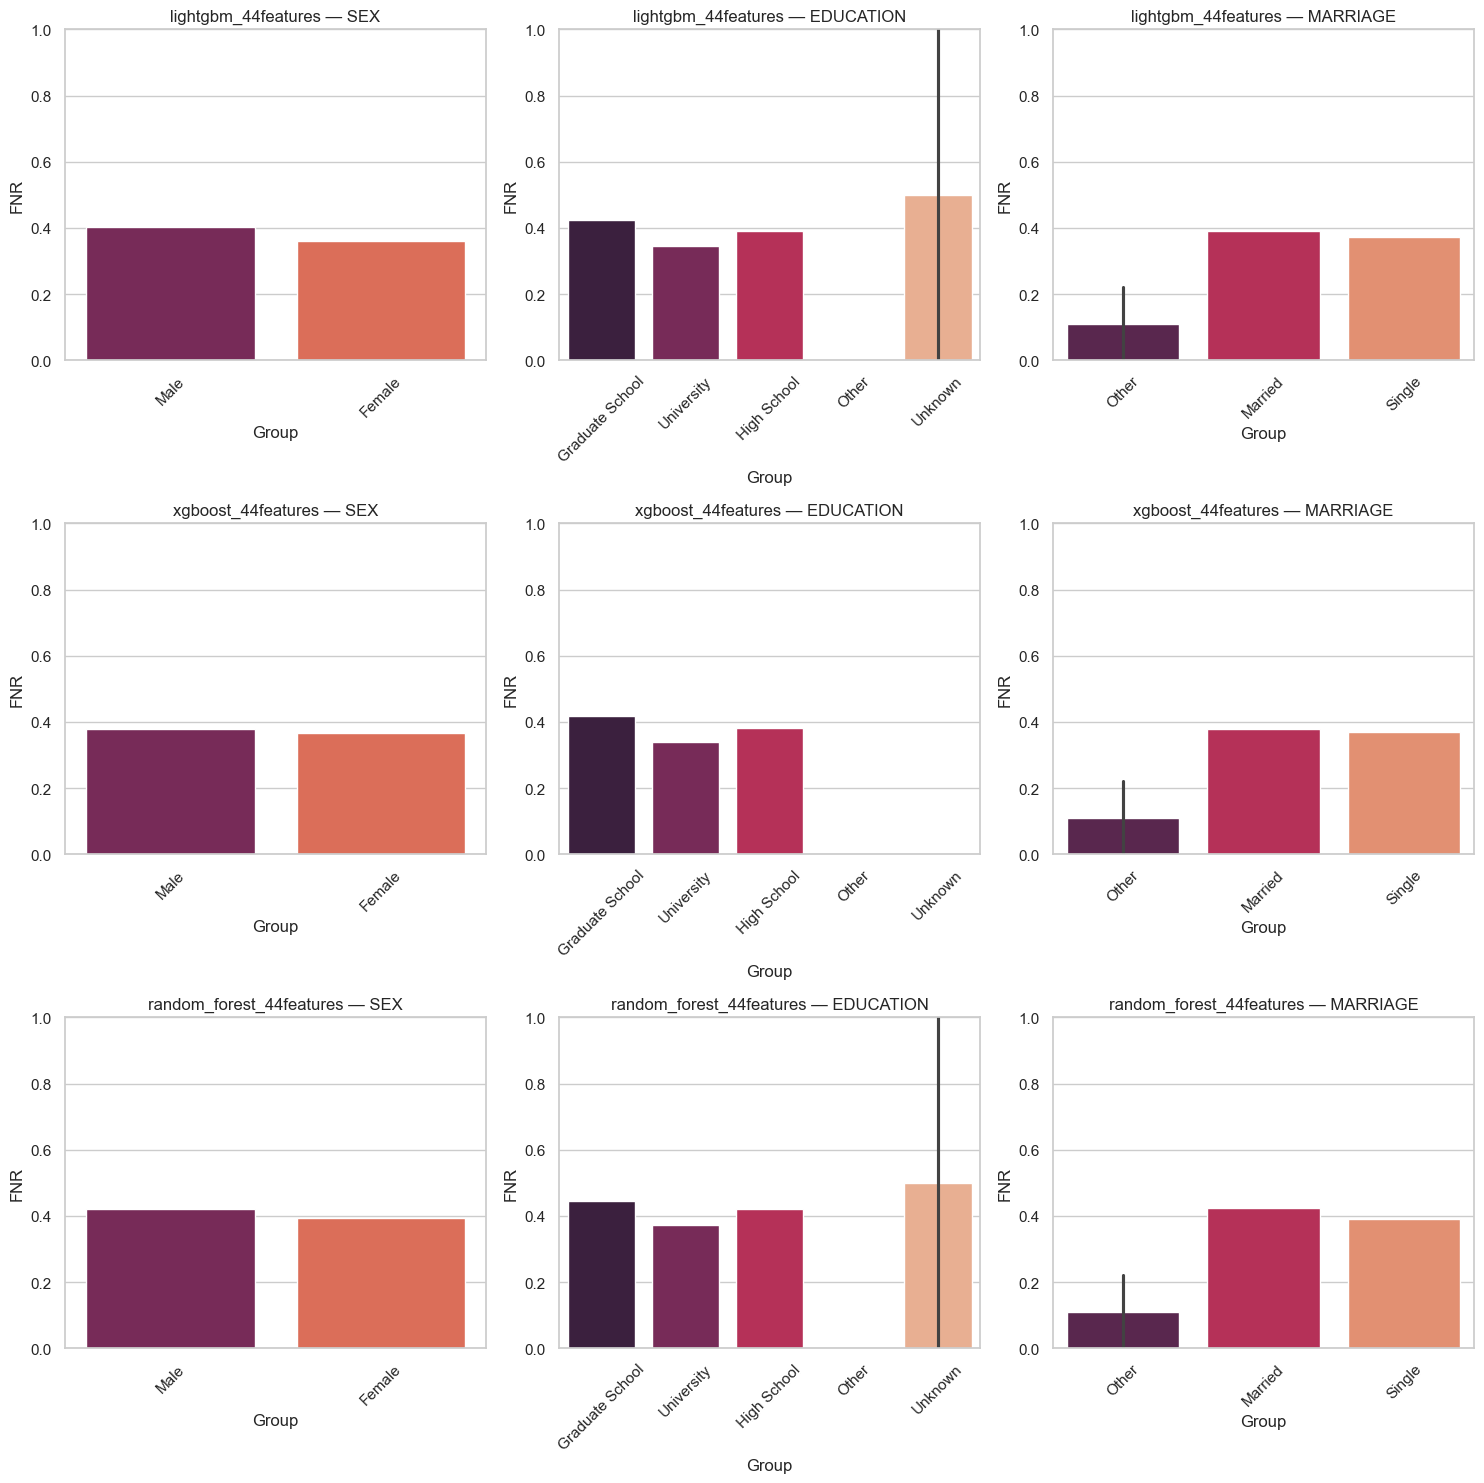

In [32]:
# Plot comparison — FNR across all models
fig, axes = plt.subplots(len(all_results), 3, figsize=(15, 5 * len(all_results)))

if len(all_results) == 1:
    axes = axes.reshape(1, -1)

for row_idx, (model_name, results) in enumerate(all_results.items()):
    for col_idx, (demo_name, df) in enumerate(results.items()):
        ax = axes[row_idx, col_idx] if len(all_results) > 1 else axes[col_idx]
        sns.barplot(data=df, x="Group", y="FNR", hue="Group", ax=ax, palette="rocket", legend=False)
        ax.set_title(f"{model_name} — {demo_name.upper()}")
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../results/fairness/all_models_fnr.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
# Disparity summary comparison
print(f"\n{'='*60}")
print("DISPARITY COMPARISON ACROSS MODELS")
print(f"{'='*60}")

summary_data = []
for model_name, results in all_results.items():
    for demo_name, df in results.items():
        if len(df) > 1:
            summary_data.append({
                "Model": model_name,
                "Demographic": demo_name,
                "Recall_Range": df["Recall"].max() - df["Recall"].min(),
                "FPR_Range": df["FPR"].max() - df["FPR"].min(),
                "FNR_Range": df["FNR"].max() - df["FNR"].min(),
            })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv("../results/fairness/disparity_summary.csv", index=False)
print(f"\nSummary saved to ../results/fairness/disparity_summary.csv")


DISPARITY COMPARISON ACROSS MODELS
                   Model Demographic  Recall_Range  FPR_Range  FNR_Range
     lightgbm_44features         sex      0.042704   0.044021   0.042704
     lightgbm_44features   education      1.000000   0.212746   1.000000
     lightgbm_44features    marriage      0.777778   0.557668   0.391566
      xgboost_44features         sex      0.012676   0.044032   0.012676
      xgboost_44features   education      1.000000   0.245009   0.418750
      xgboost_44features    marriage      0.777778   0.553834   0.379518
random_forest_44features         sex      0.029539   0.022732   0.029539
random_forest_44features   education      1.000000   0.174082   1.000000
random_forest_44features    marriage      0.777778   0.459505   0.423695

Summary saved to ../results/fairness/disparity_summary.csv


In [34]:
# Done
print("\nAll fairness visualizations complete!")


All fairness visualizations complete!
